# Exploratory Data Analysis: Mufulira Budget Revenue (2023–2026)

## 1. Introduction

This notebook performs exploratory data analysis, data-quality assessment, cleaning, preprocessing, and interpretation of the Mufulira Municipal Council structured budget revenue dataset for 2023–2026.

The dataset was produced from budget documents extracted from the official Mufulira Municipal Council website. Unlike the raw budget-table dataset, this dataset contains structured revenue records intended for easier financial analysis.

The objectives of this notebook are to:

- inspect the structure and completeness of the dataset;
- identify missing, duplicated, inconsistent, or suspicious values;
- examine the distribution of records across years and revenue categories;
- assess the quality of budget amounts;
- perform appropriate cleaning and preprocessing;
- identify meaningful patterns and findings; and
- document the decisions made during data preparation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = (
    "scrapping/budget_scraper/"
    "db-unza26-csc4792_mufulira_budget_revenue_2023_2026.csv"
)

df = pd.read_csv(file_path, sep="|", low_memory=False)

df.head()

,record_id,year,data_type,category,revenue_source,budget_amount,budget_status,description,source_title,source_url,source_type
0,BR2023_0001,2023,Revenue,NaN,CODE,2024.0,Revised Budget,CODE | REVENUE DESCRIPTION | APPROVED BUDGET 2...,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
1,BR2023_0002,2023,Revenue,Local Taxes / Rates,Local taxes/rates,1.0,Revised Budget,01 | Local taxes/rates,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
2,BR2023_0003,2023,Revenue,Local Taxes / Rates,Industrial/Commercial,8081551.0,Revised Budget,"002 | Industrial/Commercial | 7,469,086 | 8,08...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
3,BR2023_0004,2023,Revenue,Local Taxes / Rates,Mining,30471258.0,Revised Budget,"003 | Mining/Plant | 28,161,976 | 30,471,258",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
4,BR2023_0005,2023,Revenue,Local Taxes / Rates,NaN,50342746.0,Revised Budget,"SubItem Total | 43,362,061 | 46,917,750 | 50,3...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget


## 2. Initial Dataset Inspection

The initial inspection examines the number of records, available variables, data types, and sample records. This provides a basic understanding of the structure of the structured budget revenue dataset before cleaning.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 10 records:")
display(df.head(10))

Number of rows: 285
Number of columns: 11
Column names:
['record_id', 'year', 'data_type', 'category', 'revenue_source', 'budget_amount', 'budget_status', 'description', 'source_title', 'source_url', 'source_type']

Data types:
record_id             str
year                int64
data_type             str
category              str
revenue_source        str
budget_amount     float64
budget_status         str
description           str
source_title          str
source_url            str
source_type           str
dtype: object

First 10 records:


,record_id,year,data_type,category,revenue_source,budget_amount,budget_status,description,source_title,source_url,source_type
0,BR2023_0001,2023,Revenue,NaN,CODE,2.024000e+03,Revised Budget,CODE | REVENUE DESCRIPTION | APPROVED BUDGET 2...,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
1,BR2023_0002,2023,Revenue,Local Taxes / Rates,Local taxes/rates,1.000000e+00,Revised Budget,01 | Local taxes/rates,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
2,BR2023_0003,2023,Revenue,Local Taxes / Rates,Industrial/Commercial,8.081551e+06,Revised Budget,"002 | Industrial/Commercial | 7,469,086 | 8,08...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
3,BR2023_0004,2023,Revenue,Local Taxes / Rates,Mining,3.047126e+07,Revised Budget,"003 | Mining/Plant | 28,161,976 | 30,471,258",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
4,BR2023_0005,2023,Revenue,Local Taxes / Rates,NaN,5.034275e+07,Revised Budget,"SubItem Total | 43,362,061 | 46,917,750 | 50,3...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
5,BR2023_0006,2023,Revenue,Local Taxes / Rates,Levy,2.205930e+05,Revised Budget,"001 | Personal levy | 190,005 | 205,585 | 220,593",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
6,BR2023_0007,2023,Revenue,Local Taxes / Rates,NaN,2.205930e+05,Revised Budget,"SubItem Total | 190,005 | 205,585 | 220,593",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
7,BR2023_0008,2023,Revenue,Local Taxes / Rates,CODE,2.024000e+03,Revised Budget,CODE | REVENUE DESCRIPTION | APPROVED BUDGET 2...,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
8,BR2023_0009,2023,Revenue,Fees and Charges,Fees and Charges,2.000000e+00,Revised Budget,02 | Fees and Charges,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
9,BR2023_0010,2023,Revenue,Fees and Charges,Consent Fees,5.688834e+153,Revised Budget,"001 | Consent fees | 49,000 | 53,018 | 56,888 ...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget


## 3. Missing Values and Duplicate Records

This section evaluates the completeness of the structured budget revenue dataset and checks for duplicate records.

Missing values are important because incomplete financial records can affect comparisons between revenue categories and budget years. Duplicate records are also checked to prevent the same budget entry from being counted more than once.

In [3]:
print("Missing values by column:")
missing_summary = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
})

display(missing_summary)

print("Duplicate rows:", df.duplicated().sum())

Missing values by column:


,Missing,Missing_Percentage
record_id,0,0.00
year,0,0.00
data_type,0,0.00
category,4,1.40
revenue_source,39,13.68
budget_amount,0,0.00
budget_status,0,0.00
description,0,0.00
source_title,0,0.00
source_url,0,0.00


Duplicate rows: 0


## 4. Distribution of Records by Year

The dataset covers budget revenue records from 2023 to 2026. The number of records for each year is examined to determine whether the dataset is reasonably distributed across the four budget periods.

Records by year:


year
2023    59
2024    73
2025    78
2026    75
Name: count, dtype: int64

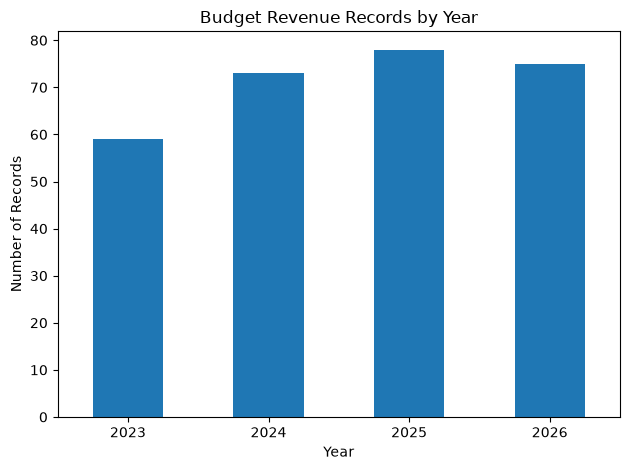

In [4]:
year_counts = df["year"].value_counts().sort_index()

print("Records by year:")
display(year_counts)

year_counts.plot(kind="bar")
plt.title("Budget Revenue Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Revenue Category Distribution

The `category` field identifies broad revenue groupings in the structured dataset. Examining these categories helps determine which types of revenue are represented and whether some categories contain substantially more records than others.

## 6. Budget Amount Quality

The `budget_amount` field is the main numerical field in the structured budget revenue dataset. Its values are inspected for missing entries, non-numeric values, unusually large values, and other possible extraction artefacts.

Because the source data was extracted from PDF documents, numerical validation is important before calculating totals or comparing budget amounts across years.

In [5]:
print("Budget amount data type:", df["budget_amount"].dtype)
print("Missing budget amounts:", df["budget_amount"].isna().sum())

print("\nSample budget amounts:")
display(df["budget_amount"].head(20))

print("\nBudget amount summary:")
display(df["budget_amount"].describe())

Budget amount data type: float64
Missing budget amounts: 0

Sample budget amounts:


0      2.024000e+03
1      1.000000e+00
2      8.081551e+06
3      3.047126e+07
4      5.034275e+07
5      2.205930e+05
6      2.205930e+05
7      2.024000e+03
8      2.000000e+00
9     5.688834e+153
10     3.213500e+04
11     6.351230e+05
12     1.207510e+05
13     1.046170e+06
14     3.788700e+04
15     4.911850e+05
16     1.850220e+05
17     1.906480e+05
18     5.132046e+06
19     1.191974e+07
Name: budget_amount, dtype: float64


Budget amount summary:


c:\Users\KALEBALIKA\Downloads\db-unza26-csc4792-Mufulira-Municipal-Council-group-8\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


count     2.850000e+02
mean     7.670125e+199
std                inf
min       0.000000e+00
25%       2.025000e+03
50%       1.983310e+05
75%       1.337341e+07
max      2.185986e+202
Name: budget_amount, dtype: float64

## 7. Budget Amount Preprocessing

The budget amount field is converted to numeric form so that financial summaries and comparisons can be performed reliably.

Values that cannot be interpreted as valid numbers are converted to missing values rather than being assigned arbitrary values.

In [6]:
df_cleaned = df.copy()

df_cleaned["budget_amount"] = pd.to_numeric(
    df_cleaned["budget_amount"],
    errors="coerce"
)

print("Budget amount type after conversion:")
print(df_cleaned["budget_amount"].dtype)

print("Values that could not be converted:",
      df_cleaned["budget_amount"].isna().sum())

Budget amount type after conversion:
float64
Values that could not be converted: 0


## 8. Suspicious Budget Amounts

Extremely large or unusually small budget values may indicate extraction errors. The minimum and maximum values are therefore inspected before financial aggregation.

In [7]:
print("Smallest budget amounts:")
display(df_cleaned.nsmallest(10, "budget_amount")[
    ["year", "category", "revenue_source", "budget_amount"]
])

print("\nLargest budget amounts:")
display(df_cleaned.nlargest(10, "budget_amount")[
    ["year", "category", "revenue_source", "budget_amount"]
])

Smallest budget amounts:


,year,category,revenue_source,budget_amount
97,2024,Fees and Charges,NaN,0.0
1,2023,Local Taxes / Rates,Local taxes/rates,1.0
60,2024,Local Taxes / Rates,Local taxes/rates,1.0
120,2024,Capital Expenditure,MTEF preparation 01 Budgets Prepared,1.0
133,2025,Local Taxes / Rates,Local taxes/rates,1.0
211,2026,Local Taxes / Rates,Local taxes/rates,1.0
264,2026,Expenditure,Council Commercial ventures revamped 01 Number...,1.0
271,2026,Expenditure,Market Shelters Rehabilitated 01 Number of mar...,1.0
8,2023,Fees and Charges,Fees and Charges,2.0
67,2024,Fees and Charges,Fees and Charges,2.0



Largest budget amounts:


,year,category,revenue_source,budget_amount
198,2025,Expenditure,01Personal Emoluments 01Salaries and Wages 01(...,2.185986e+202
47,2023,Expenditure,031 Street Lighting 7 Recreation Culture and R...,1.633021e+157
9,2023,Fees and Charges,Consent Fees,5.688834e+153
192,2025,Expenditure,01Personal Emoluments 01Salaries and Wages 01F...,4.805149e+126
200,2025,Expenditure,01Personal Emoluments 01Salaries and Wages 01R...,4.030947e+81
275,2026,Expenditure,01Personal Emoluments 01Salaries and Wages 02O...,3.072871e+69
182,2025,Expenditure,02Use of Goods and Services 02General Operatio...,1.524276e+69
191,2025,Expenditure,01Personal Emoluments 01Salaries and Wages 01C...,7.890438e+67
197,2025,Expenditure,01Personal Emoluments 01Salaries and Wages 01C...,1.139012e+67
268,2026,Expenditure,6 Housing and Community Amenities 001General A...,1.582226e+65


## 9. Categorical Consistency

The structured dataset contains several categorical fields, including `data_type`, `category`, `revenue_source`, and `budget_status`.

These fields are inspected for inconsistent capitalization, unnecessary whitespace, missing values, or unexpected categories. Standardizing categorical values improves grouping, counting, and comparison during analysis.

In [8]:
categorical_columns = [
    "data_type",
    "category",
    "revenue_source",
    "budget_status"
]

for column in categorical_columns:
    print(f"\nUnique values in {column}:")
    display(
        df_cleaned[column]
        .astype("string")
        .str.strip()
        .value_counts(dropna=False)
    )


Unique values in data_type:


data_type
Revenue        211
Budget          39
Expenditure     35
Name: count, dtype: Int64


Unique values in category:


category
Fees and Charges       125
Expenditure             67
Local Taxes / Rates     29
Grants                  20
Goods and Services      18
Personal Emoluments     17
<NA>                     4
LGEF                     3
Capital Expenditure      2
Name: count, dtype: Int64


Unique values in revenue_source:


revenue_source
<NA>                                                                                                                                                                                                                                         39
CODE                                                                                                                                                                                                                                         16
Levy                                                                                                                                                                                                                                         15
ECONOMIC CLASSIFICATION                                                                                                                                                                                                                      15
Rent                     


Unique values in budget_status:


budget_status
Revised Budget     174
Approved Budget     68
Actual              42
Budget Estimate      1
Name: count, dtype: Int64

## 10. Text Standardization

Leading and trailing whitespace is removed from categorical and descriptive text fields. This helps prevent equivalent values from being treated as different categories because of formatting differences.

In [9]:
text_columns = df_cleaned.select_dtypes(
    include=["object", "string"]
).columns

for column in text_columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype("string")
        .str.strip()
    )

print("Text fields standardized.")

Text fields standardized.


## 11. Revenue Records by Year and Category

The cleaned dataset is examined across budget years and revenue categories. This provides an overview of how the council's structured revenue records are distributed over time and across different revenue groupings.

In [10]:
year_category = pd.crosstab(
    df_cleaned["year"],
    df_cleaned["category"]
)

display(year_category)

category,Capital Expenditure,Expenditure,Fees and Charges,Goods and Services,Grants,LGEF,Local Taxes / Rates,Personal Emoluments
year,,,,,,,,
2023,0,8,32,4,6,0,7,1
2024,2,17,31,4,4,1,7,6
2025,0,20,33,5,5,1,7,6
2026,0,22,29,5,5,1,8,4


## 12. Total Budget Amount by Year

The total recorded budget amount is calculated for each budget year. This provides a high-level comparison of the monetary values represented in the structured revenue dataset.

Only valid numeric budget amounts are included in the aggregation.

Total budget amount by year:


year
2023    1.633590e+157
2024     5.421291e+60
2025    2.185986e+202
2026     3.073029e+69
Name: budget_amount, dtype: float64

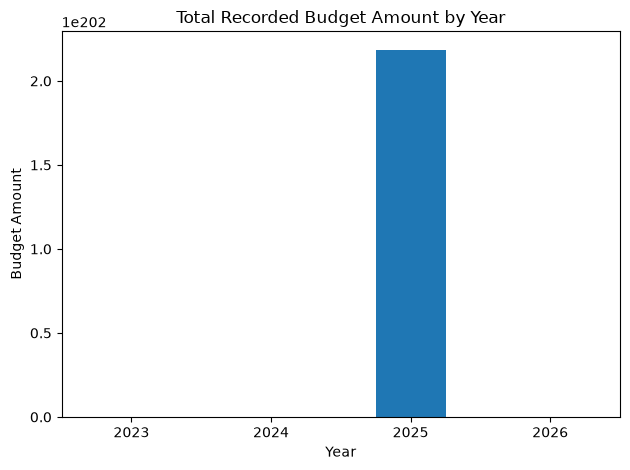

In [11]:
annual_budget = (
    df_cleaned
    .groupby("year", dropna=False)["budget_amount"]
    .sum()
    .sort_index()
)

print("Total budget amount by year:")
display(annual_budget)

annual_budget.plot(kind="bar")
plt.title("Total Recorded Budget Amount by Year")
plt.xlabel("Year")
plt.ylabel("Budget Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Revenue Source Analysis

The `revenue_source` field identifies the specific source associated with each structured revenue record. Examining the frequency of revenue sources helps identify which sources occur most frequently in the dataset and provides additional context for the council's revenue structure.

In [12]:
revenue_source_counts = (
    df_cleaned["revenue_source"]
    .value_counts(dropna=False)
)

print("Top revenue sources:")
display(revenue_source_counts.head(20))

Top revenue sources:


revenue_source
<NA>                                                                                                                                                 39
CODE                                                                                                                                                 16
Levy                                                                                                                                                 15
ECONOMIC CLASSIFICATION                                                                                                                              15
Rent                                                                                                                                                 12
01Personal Emoluments 01Salaries and Wages 02Use of Goods and Services 02General Operations 04Assets 01Non-Financial Assets (Capital Expenditure)     9
PROGRAMME/SUBPROGRAMME                                                   

## 14. Budget Status Analysis

The `budget_status` field indicates the budget status associated with each record. Its distribution is examined to determine whether the structured dataset contains different budget classifications and whether any records have missing status information.

Budget status distribution:


budget_status
Revised Budget     174
Approved Budget     68
Actual              42
Budget Estimate      1
Name: count, dtype: Int64

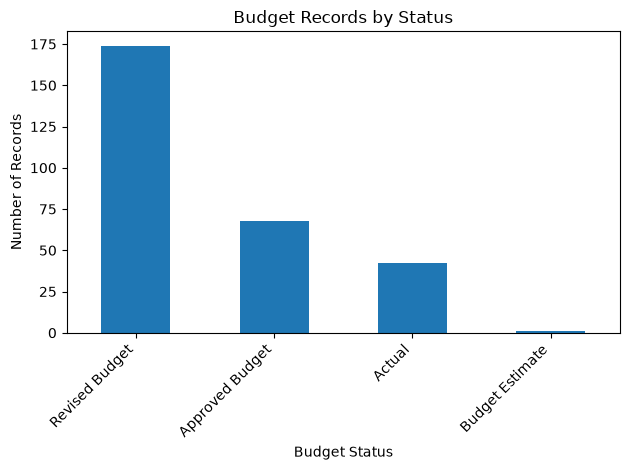

In [13]:
status_counts = (
    df_cleaned["budget_status"]
    .value_counts(dropna=False)
)

print("Budget status distribution:")
display(status_counts)

status_counts.plot(kind="bar")
plt.title("Budget Records by Status")
plt.xlabel("Budget Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 15. Top Revenue Sources by Total Budget Amount

The total recorded budget amount is aggregated by revenue source. This highlights the revenue sources associated with the largest monetary values in the structured dataset.

Only valid numeric budget amounts are included.

In [14]:
top_revenue_amounts = (
    df_cleaned
    .groupby("revenue_source", dropna=False)["budget_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Top revenue sources by total recorded budget amount:")
display(top_revenue_amounts.head(15))

Top revenue sources by total recorded budget amount:


revenue_source
01Personal Emoluments 01Salaries and Wages 01(cid:9)Procurement 01Administration 01Town Clerk 05Accounting 08(cid:9)Auditing 02Other Emoluments 01Administration 03Personnel Related Costs 01Establishment 02Use of Goods and Services 02General Operations 01(cid:9)Procurement 01Establishment 01Public Relations 02Mayor 02Stores 05Accounting 04Assets 01Non-Financial Assets (Capital Expenditure) 01Establishment 02Deeds 02Mayor 02Stores 04Estates 05Contracts and Licensing 08(cid:9)Auditing 05Liabilities 01 Outstanding Bills 01Administration 01Establishment                                                                             2.185986e+202
031 Street Lighting 7 Recreation Culture and Religion 039 Library Services 042 Sports Promotion 8 Education and Skills Development 005 Early Childhood Education 010 Adult Literacy 10 Public Order and Safety 014 Building Regulations 018 Community Policing 041 Fire Protection Services 11 Management and Support Services 001 (cid:9)Human Reso

## 16. Key Findings

The exploratory analysis of the structured Mufulira Municipal Council budget revenue dataset produced several important observations:

- The dataset contains structured revenue records covering the 2023–2026 budget years.
- Revenue records are distributed across multiple revenue categories and sources.
- The `budget_amount` field required numeric conversion before financial aggregation could be performed.
- Inspection of the largest values was necessary because PDF-based extraction can introduce malformed or unusually large numerical values.
- Text fields were standardized by removing unnecessary leading and trailing whitespace.
- The annual and category-level analysis provides a basis for comparing the council's recorded revenue structure across budget years.
- Records with values that could not be reliably interpreted as numeric were treated as missing rather than assigned incorrect financial values.

The structured dataset is therefore more suitable for financial analysis than the raw budget-table dataset, while the raw dataset remains useful for tracing records back to their original extracted tables.

## 17. Cleaning and Preprocessing Summary

The following preprocessing steps were applied:

1. Missing values were identified for all fields.
2. Duplicate records were checked.
3. Budget amounts were converted to numeric values using coercion for invalid entries.
4. Suspiciously large and small monetary values were inspected.
5. Leading and trailing whitespace was removed from text fields.
6. Categorical fields were inspected for consistency.
7. Records with valid numeric budget amounts were used for financial aggregation.
8. Original descriptive and source fields were retained to preserve traceability.

## 18. Conclusion

The Mufulira Municipal Council Budget Revenue 2023–2026 dataset provides a structured representation of revenue-related budget records extracted from official municipal budget documents.

The EDA identified the dataset's temporal coverage, revenue categories, revenue sources, budget statuses, and financial-value characteristics. Preprocessing improved the consistency of the data while avoiding the introduction of fabricated financial values.

The resulting dataset is suitable for exploratory financial analysis, including comparisons across years, categories, and revenue sources. However, unusually large or malformed extracted values should be treated cautiously and, where necessary, verified against the original budget documents.

In [15]:
print("Original number of rows:", len(df))
print("Cleaned number of rows:", len(df_cleaned))
print("Duplicate rows after cleaning:", df_cleaned.duplicated().sum())
print("Missing budget amounts:", df_cleaned["budget_amount"].isna().sum())
print("Number of columns:", df_cleaned.shape[1])

Original number of rows: 285
Cleaned number of rows: 285
Duplicate rows after cleaning: 0
Missing budget amounts: 0
Number of columns: 11
